## 1. Define Project

Project Link:
https://www.kaggle.com/competitions/predict-student-performance-from-game-play/data

Description:
This project aims to predict student performance based on gameplay data. The dataset contains user interaction features collected during gameplay sessions. The goal is to classify whether a student will correctly answer questions based on these features.

Data Description:
The dataset consists of tabular data with multiple features including session information, event data, and user behavior metrics. The target variable represents whether the student answered correctly.

## 2. Data Loading & Initial Look

In [177]:
import pandas as pd

# Load smaller portion to avoid crashes
train = pd.read_csv("data/train.csv", nrows=500000)
test = pd.read_csv("data/test.csv", nrows=500000)

labels = pd.read_csv("data/train_labels.csv")

In [178]:
train.head()

,session_id,index,elapsed_time,event_name,name,level,page,room_coor_x,room_coor_y,screen_coor_x,screen_coor_y,hover_duration,text,fqid,room_fqid,text_fqid,fullscreen,hq,music,level_group
0,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,undefined,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4
1,20090312431273200,1,1323,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,"Whatcha doing over there, Jo?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
2,20090312431273200,2,831,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,Just talking to Teddy.,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
3,20090312431273200,3,1147,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,I gotta run to my meeting!,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
4,20090312431273200,4,1863,person_click,basic,0,NaN,-412.991405,-159.314686,381.0,494.0,NaN,"Can I come, Gramps?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4


In [179]:
labels.head()

,session_id,correct
0,20090312431273200_q1,1
1,20090312433251036_q1,0
2,20090312455206810_q1,1
3,20090313091715820_q1,0
4,20090313571836404_q1,1


In [180]:
# Prints out the basic categories + missing values
print(f"Rows: {train.shape} Features: {train.shape[1]}")
print()
print("Missing values per column:")
print(train.isnull().sum())
print()
train.info()

Rows: (500000, 20) Features: 20

Missing values per column:
session_id             0
index                  0
elapsed_time           0
event_name             0
name                   0
level                  0
page              489546
room_coor_x        44347
room_coor_y        44347
screen_coor_x      44347
screen_coor_y      44347
hover_duration    456992
text              319811
fqid              154747
room_fqid              0
text_fqid         319810
fullscreen             0
hq                     0
music                  0
level_group            0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   session_id      500000 non-null  int64  
 1   index           500000 non-null  int64  
 2   elapsed_time    500000 non-null  int64  
 3   event_name      500000 non-null  str    
 4   name            500000 non-null  str    
 5  

In [181]:
# Create a comprehensive table outlining feature types, missing counts, and unique values
summary_table = pd.DataFrame({
    'Data Type': train.dtypes,
    'Missing Values': train.isnull().sum(),
    'Unique Values': train.nunique()
})
display(summary_table)

# Define and check for outliers
print("Outlier Definition: A value is considered an outlier if it is more than 3 standard deviations away from the mean.")

elapsed_time_mean = train['elapsed_time'].mean()
elapsed_time_std = train['elapsed_time'].std()
outliers = train[(train['elapsed_time'] > elapsed_time_mean + 3 * elapsed_time_std) | 
                 (train['elapsed_time'] < elapsed_time_mean - 3 * elapsed_time_std)]
print(f"Number of outliers in 'elapsed_time': {len(outliers)}")


,Data Type,Missing Values,Unique Values
session_id,int64,0,443
index,int64,0,4235
elapsed_time,int64,0,460391
event_name,str,0,11
name,str,0,6
level,int64,0,23
page,float64,489546,7
room_coor_x,float64,44347,383807
room_coor_y,float64,44347,283295
screen_coor_x,float64,44347,3587


Outlier Definition: A value is considered an outlier if it is more than 3 standard deviations away from the mean.
Number of outliers in 'elapsed_time': 7969


**Feature Summary:**
Extracting the data type, value ranges, missing counts, and outlier status for each feature to understand the dataset structure.

# Feature summary table


In [234]:
import pandas as pd

# Create a comprehensive summary table
summary_data = []
for col in train.columns:
    # Explicitly check if the column is a numeric data type
    is_numeric = pd.api.types.is_numeric_dtype(train[col])
    dtype = 'Numerical' if is_numeric and train[col].nunique() > 2 else 'Categorical/Binary'
    
    missing = train[col].isnull().sum()
    
    # Get values/range
    if dtype == 'Numerical':
        val_range = f"{train[col].min()} to {train[col].max()}"
    else:
        val_range = ", ".join(map(str, train[col].dropna().unique()[:3])) + "..."
    
    # Check for outliers (using 3 standard deviations for numerical features)
    outlier_status = "None"
    if dtype == 'Numerical':
        mean = train[col].mean()
        std = train[col].std()
        outliers_count = len(train[(train[col] > mean + 3 * std) | (train[col] < mean - 3 * std)])
        if outliers_count > 0:
            outlier_status = f"Yes ({outliers_count})"
    
    summary_data.append([col, dtype, val_range, missing, outlier_status])

final_summary_table = pd.DataFrame(summary_data, columns=['Feature', 'Data Type', 'Range / Values', 'Missing Values', 'Outliers Found'])
display(final_summary_table)


,Feature,Data Type,Range / Values,Missing Values,Outliers Found
0,session_id,Categorical/Binary,"20090312431273200, 20090312433251036, 20090312...",0,None
1,index,Numerical,0 to 4234,0,Yes (7613)
2,elapsed_time,Numerical,0 to 156402689,0,Yes (7969)
3,event_name,Categorical/Binary,"cutscene_click, person_click, navigate_click...",0,None
4,name,Categorical/Binary,"basic, undefined, close...",0,None
5,level,Numerical,0 to 22,0,None
6,page,Numerical,0.0 to 6.0,489546,None
7,room_coor_x,Numerical,-1986.058384823103 to 1255.4453230483698,44347,Yes (3632)
8,room_coor_y,Numerical,-915.8869767292648 to 536.7358300045953,44347,Yes (3750)
9,screen_coor_x,Numerical,0.0 to 1599.0,44347,Yes (723)


In [233]:
# Printing out the class distribution percentages.

print("Class distribution:")
print(labels['correct'].value_counts())
print("\nClass balance (%):")
print(labels['correct'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Class distribution:
correct
1    5501
0    2473
Name: count, dtype: int64

Class balance (%):
correct
1    69.0%
0    31.0%
Name: proportion, dtype: str


## 3. Feature Understanding

**1. Column Overview**

In [184]:
train.columns

Index(['session_id', 'index', 'elapsed_time', 'event_name', 'name', 'level',
       'page', 'room_coor_x', 'room_coor_y', 'screen_coor_x', 'screen_coor_y',
       'hover_duration', 'text', 'fqid', 'room_fqid', 'text_fqid',
       'fullscreen', 'hq', 'music', 'level_group'],
      dtype='str')


**2. Feature Type Exploration**

Categorical features:

In [185]:
train["event_name"].value_counts()

event_name
navigate_click        213023
person_click          113852
cutscene_click         50069
object_click           41891
object_hover           22467
map_hover              20541
notification_click     12090
notebook_click         10454
map_click              10095
observation_click       4179
checkpoint              1339
Name: count, dtype: int64

In [186]:
train["level_group"].value_counts()

level_group
13-22    258153
5-12     168970
0-4       72877
Name: count, dtype: int64

In [187]:
train["name"].value_counts()

name
undefined    241549
basic        240643
close         12793
open           4404
prev            407
next            204
Name: count, dtype: int64

*Numerical features:*

In [188]:
train["elapsed_time"].describe()

count    5.000000e+05
mean     2.628693e+06
std      9.349558e+06
min      0.000000e+00
25%      4.816570e+05
50%      1.112874e+06
75%      1.957996e+06
max      1.564027e+08
Name: elapsed_time, dtype: float64

In [189]:
train["level"].describe()

count    500000.000000
mean         12.276472
std           6.466056
min           0.000000
25%           6.000000
50%          13.000000
75%          18.000000
max          22.000000
Name: level, dtype: float64

**3. Feature Classification**

The dataset contains:

- Numerical features include elapsed_time, level, coordinates
- Categorical features include event_name, fqid, level_group
- Binary features include fullscreen, music, hq
- session_id is an identifier and not used for modeling

Some features such as session_id are not useful for prediction and will be excluded from modeling.

**Observations:**
- event_name has multiple categories with uneven distribution.
- elapsed_time varies significantly, indicating different session lengths.
- Several categorical features may require encoding before machine learning.

## 4. Target Variable and Data Preparations

**1. Load Labels**

In [190]:
labels = pd.read_csv("data/train_labels.csv")

**2. Identify Target**

In [191]:
labels.columns

Index(['session_id', 'correct'], dtype='str')

**Markdown**

The target variable is correct, which indicates whether a student answered correctly (1) or incorrectly (0). This is a binary classification problem.

**3. Fix session_id type**

In [192]:
# Convert train session_id to string
train["session_id"] = train["session_id"].astype(str)

# Extract base session_id from labels (remove _q1, _q2, etc.)
labels["base_session_id"] = labels["session_id"].str.split("_").str[0]

# Keep only matching sessions (reduces size and prevents crashes)
labels = labels[labels["base_session_id"].isin(train["session_id"])]

# Merge on base session id
train_merged = pd.merge(
    train,
    labels,
    left_on="session_id",
    right_on="base_session_id"
)

**4. Merge Datasets**

In [193]:
train_merged.head()

,session_id_x,index,elapsed_time,event_name,name,level,page,room_coor_x,room_coor_y,screen_coor_x,...,fqid,room_fqid,text_fqid,fullscreen,hq,music,level_group,session_id_y,correct,base_session_id
0,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,...,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4,20090312431273200_q1,1,20090312431273200
1,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,...,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4,20090312431273200_q2,1,20090312431273200
2,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,...,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4,20090312431273200_q3,1,20090312431273200
3,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,...,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4,20090312431273200_q4,1,20090312431273200
4,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,...,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4,20090312431273200_q5,1,20090312431273200


In [194]:
train_merged["correct"].value_counts()

correct
1    5876165
0    3123835
Name: count, dtype: int64

**5. Check target distribution**

In [195]:
train_merged["correct"].value_counts()

correct
1    5876165
0    3123835
Name: count, dtype: int64

**6. Data alignment note**

session_id was converted to string to ensure compatibility before merging.

## 5. Data Visualization

Small visualization dataset to prevent crashes

In [196]:
viz_df = train_merged.sample(100000, random_state=42)

**Class Distribution**

<Axes: xlabel='correct'>

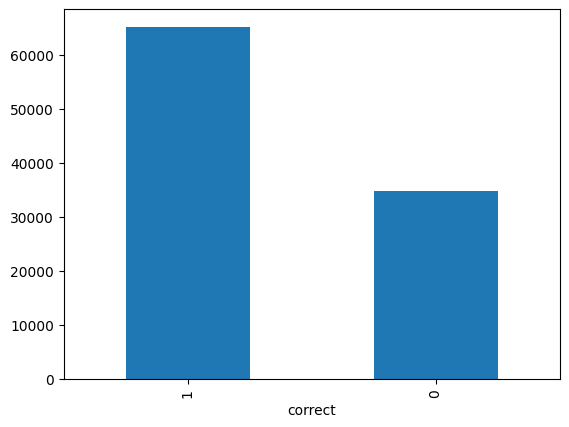

In [197]:
viz_df["correct"].value_counts().plot(kind="bar")

The dataset shows the distribution of correct and incorrect responses. This helps identify whether class imbalance exists.

**2. Numerical Feature vs Target**

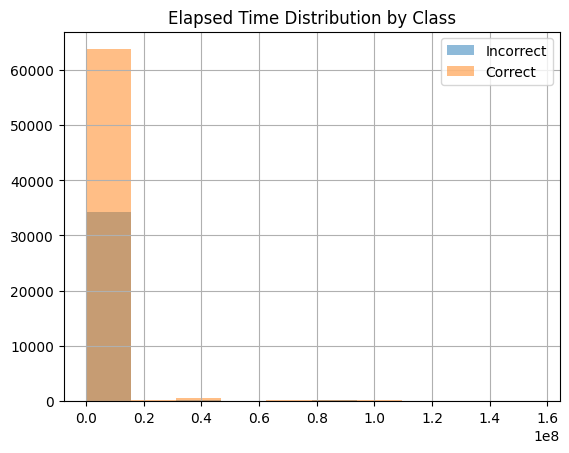

In [198]:
import matplotlib.pyplot as plt

viz_df[viz_df["correct"] == 0]["elapsed_time"].hist(alpha=0.5)
viz_df[viz_df["correct"] == 1]["elapsed_time"].hist(alpha=0.5)

plt.legend(["Incorrect", "Correct"])
plt.title("Elapsed Time Distribution by Class")
plt.show()

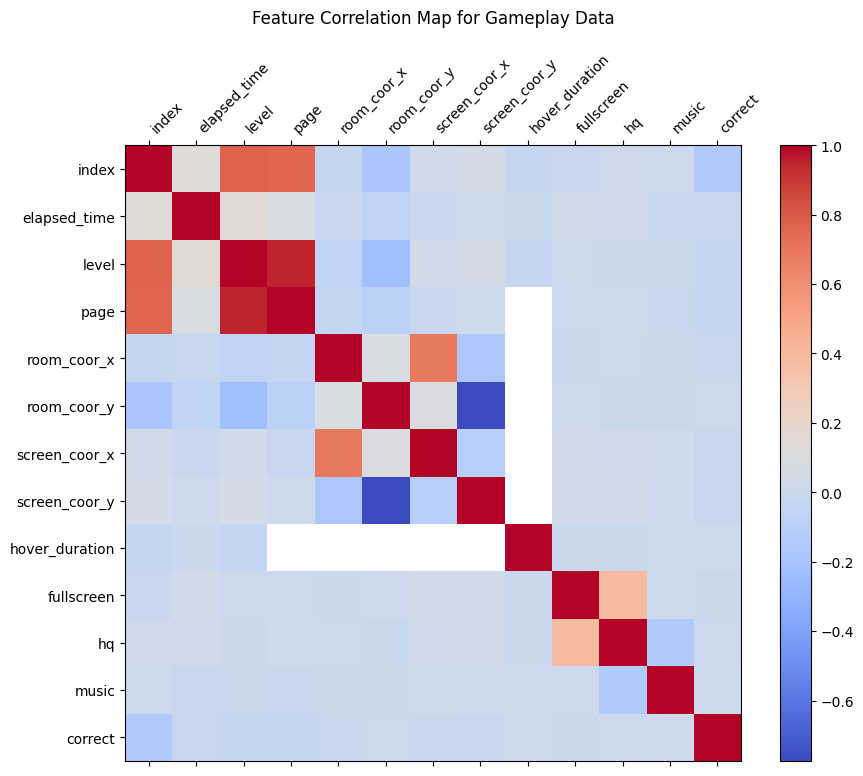

In [199]:
# Calculate correlation matrix for numeric features to find relationships and potential leaks
corr_matrix = viz_df.select_dtypes(include=['number']).corr()

# Plot correlation matrix using matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)

# Set axis ticks and labels to show the feature names
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)

plt.title('Feature Correlation Map for Gameplay Data', pad=20)
plt.show()


The distribution of elapsed_time differs between correct and incorrect responses, suggesting it may be useful for prediction.

**3. Another Numerical Feature**

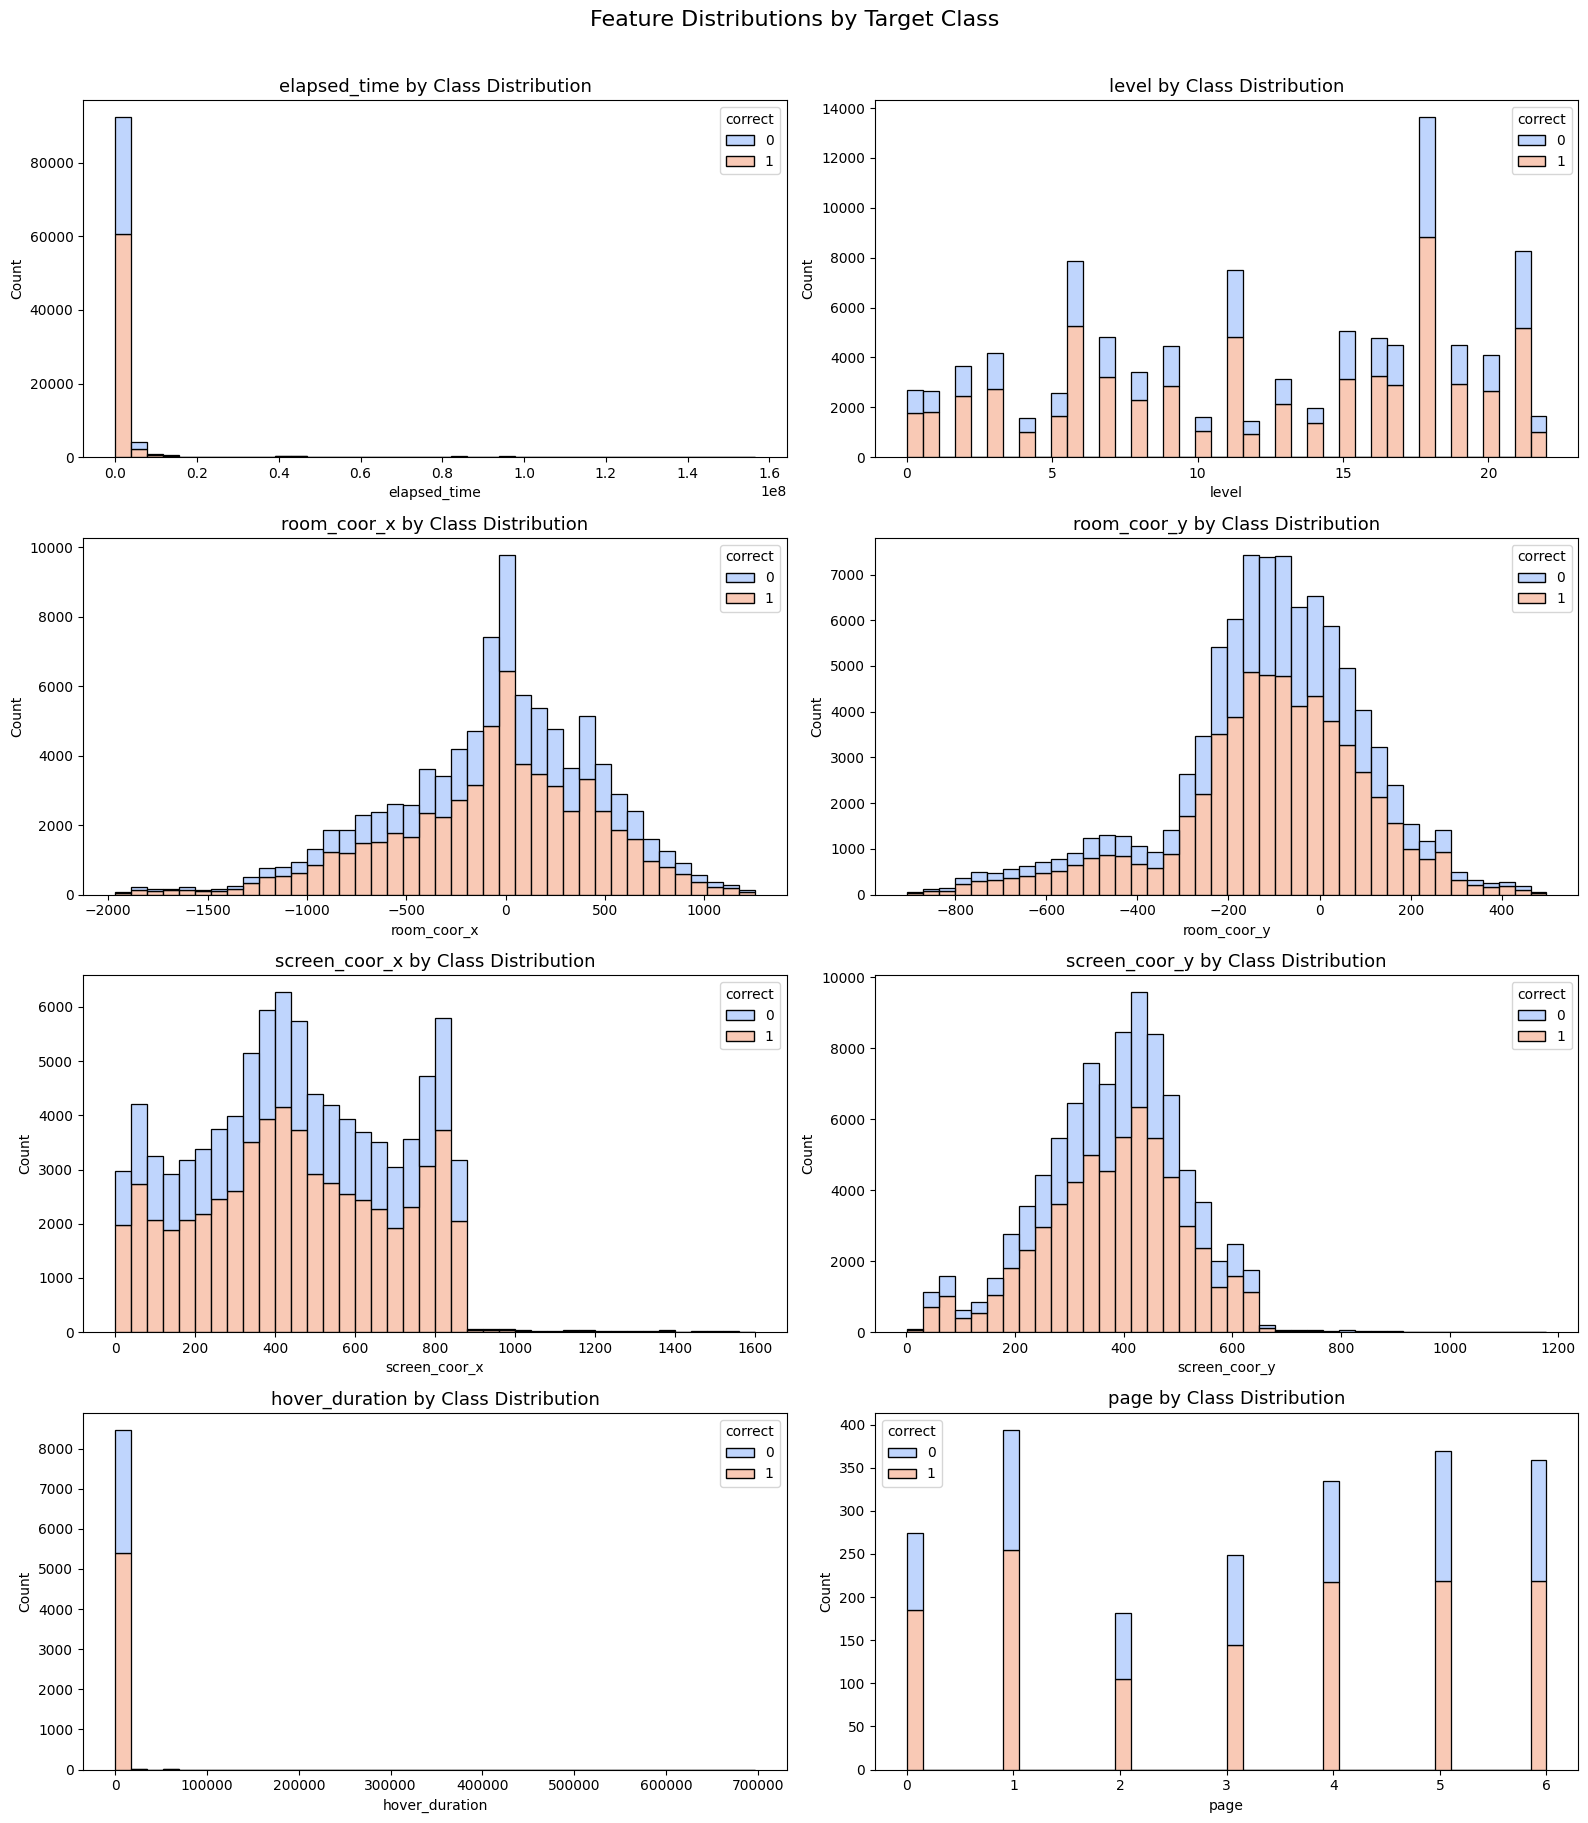

In [232]:
import seaborn as sns
import matplotlib.pyplot as plt

# including ALL numerical features 
numerical_features = ['elapsed_time', 'level', 'room_coor_x', 'room_coor_y', 'screen_coor_x', 'screen_coor_y', 'hover_duration', 'page']
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=viz_df, 
        x=feature, 
        hue='correct', 
        multiple='stack',
        ax=axes[i], 
        bins=40, 
        palette='coolwarm'
    )
    axes[i].set_title(f'{feature} by Class Distribution', fontsize=13)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions by Target Class', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

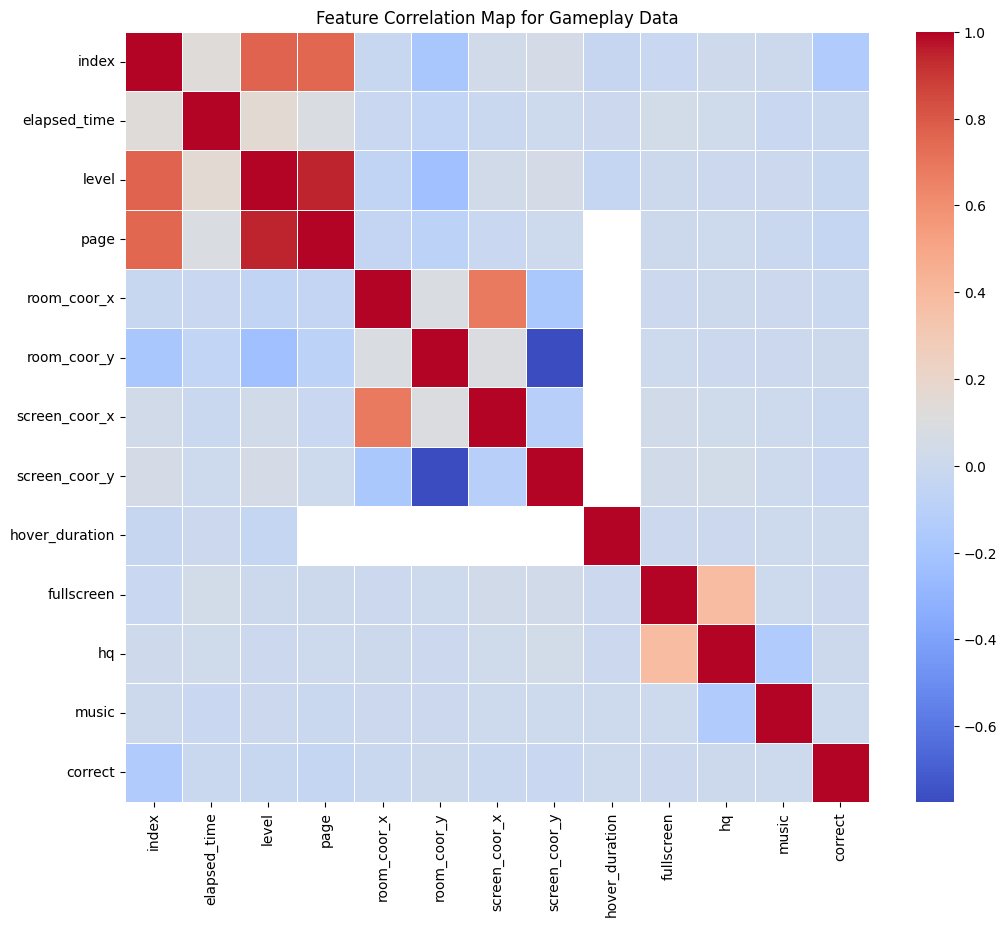

In [201]:
import seaborn as sns

# Calculate correlation matrix for numeric features to find relationships and potential leaks
corr_matrix = viz_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Map for Gameplay Data')
plt.show()


**4. Categorical Feature vs Target**

In [202]:
pd.crosstab(viz_df["event_name"], viz_df["correct"])

correct,0,1
event_name,,
checkpoint,85,165
cutscene_click,3214,6963
map_click,725,1261
map_hover,1512,2448
navigate_click,15311,27140
notebook_click,817,1345
notification_click,809,1700
object_click,3098,5251
object_hover,1562,2977


Certain event types appear more frequently in correct vs incorrect responses, indicating predictive potential.

**5. Another Categorical Feature**

In [203]:
pd.crosstab(viz_df["level_group"], viz_df["correct"])

correct,0,1
level_group,,
0-4,4937,9784
13-22,18247,33347
5-12,11665,22020


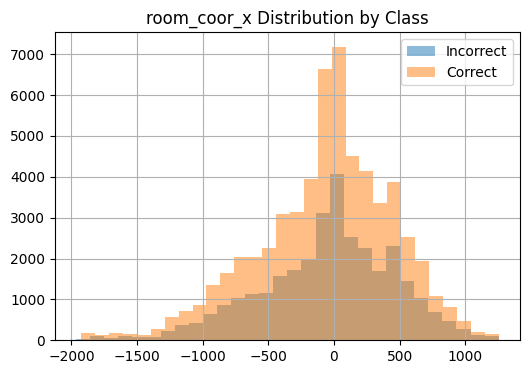

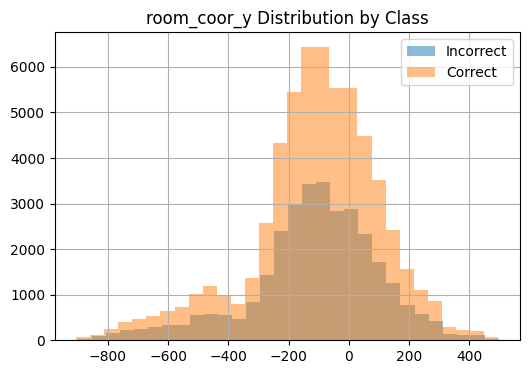

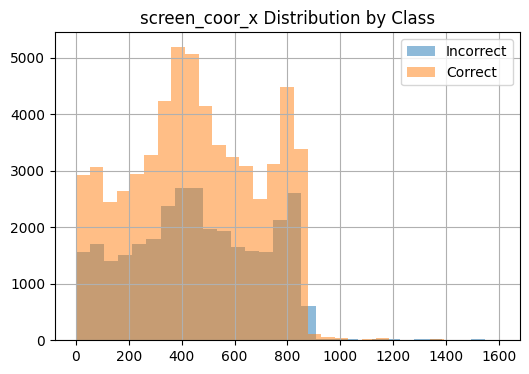

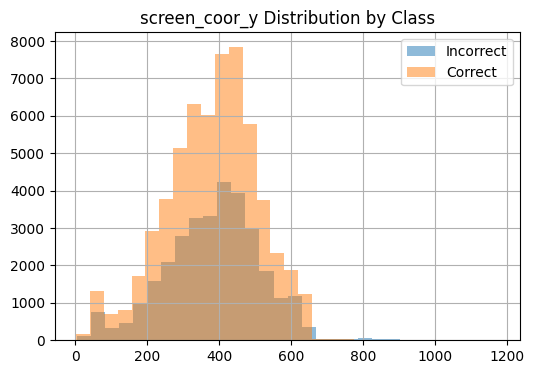

In [204]:
# Visualizing all other relevant numerical features between classes
numeric_features = ['room_coor_x', 'room_coor_y', 'screen_coor_x', 'screen_coor_y']

for col in numeric_features:
    plt.figure(figsize=(6,4))
    viz_df[viz_df["correct"] == 0][col].hist(alpha=0.5, label="Incorrect", bins=30)
    viz_df[viz_df["correct"] == 1][col].hist(alpha=0.5, label="Correct", bins=30)
    plt.legend()
    plt.title(f"{col} Distribution by Class")
    plt.show()

**6. Feature Insights**

- elapsed_time shows variation between classes and may be predictive
- event_name distribution differs significantly across outcomes
- level_group may capture progression patterns related to performance


## 6. Data Cleaning & Preparation for Machine Learning

**Steps taken:**
1. **Missing values:** Filled missing numericals with 0 or -1, and categoricals with "unknown". Remaining NaNs filled with median.
2. **Unecessary Columns:** Dropped high-cardinality text and ID columns.
3. **Outlier treatment:** IQR based outliers removed for 'elapsed_time'.
4. **Target encoding:** Binary-encoded target is already present ('correct').
5. **Standard Scaling:** Numerical features scaled to zero mean, unit variance.


In [205]:
ml_df = train_merged.sample(100000, random_state=42)

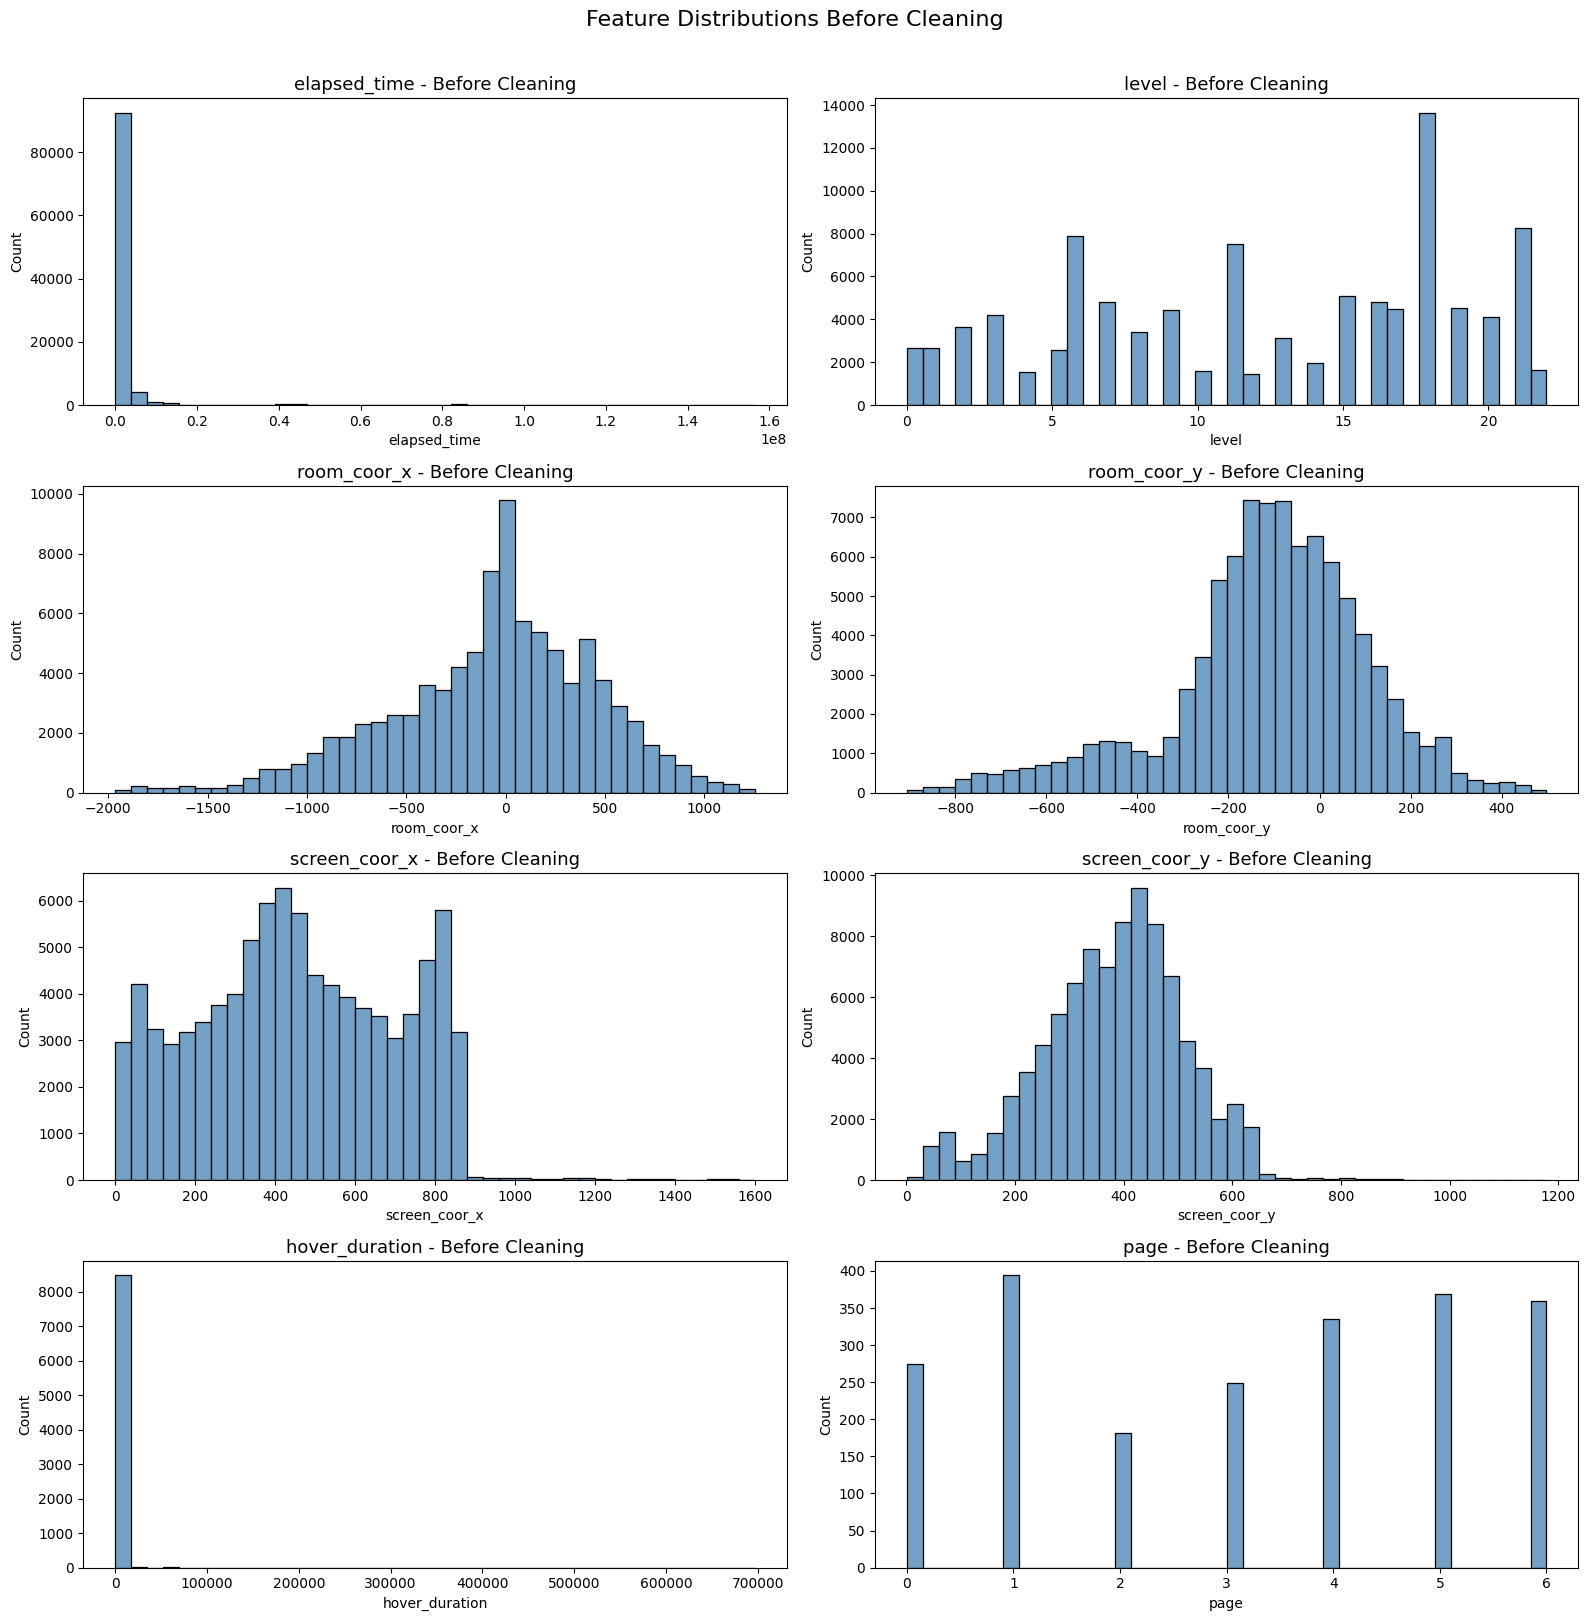

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

# BEFORE CLEANING PLOT (To satisfy the guideline requirement)
numerical_features_raw = ['elapsed_time', 'level', 'room_coor_x', 'room_coor_y', 'screen_coor_x', 'screen_coor_y', 'hover_duration', 'page']

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, feature in enumerate(numerical_features_raw):
    sns.histplot(data=ml_df, x=feature, ax=axes[i], bins=40, color='steelblue')
    axes[i].set_title(f'{feature} - Before Cleaning', fontsize=13)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions Before Cleaning', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


**1. Handle Missing Values**

In [207]:
ml_df.isnull().sum()

session_id_x           0
index                  0
elapsed_time           0
event_name             0
name                   0
level                  0
page               97838
room_coor_x         8749
room_coor_y         8749
screen_coor_x       8749
screen_coor_y       8749
hover_duration     91501
text               63697
fqid               31049
room_fqid              0
text_fqid          63697
fullscreen             0
hq                     0
music                  0
level_group            0
session_id_y           0
correct                0
base_session_id        0
dtype: int64

**Fill missing numerical values**

In [208]:
ml_df["hover_duration"] = ml_df["hover_duration"].fillna(0)
ml_df["page"] = ml_df["page"].fillna(-1)

**Fill missing categorical values**

In [209]:
ml_df["text"] = ml_df["text"].fillna("unknown")

Missing numerical values were filled with default values (0 or -1), and missing categorical values were filled with "unknown" to preserve information.

In [210]:
# Fill any remaining NaNs (like room and screen coordinates) with the median
# This ensures algorithms like Logistic Regression won't crash
ml_df = ml_df.fillna(ml_df.median(numeric_only=True))

# Verify there are no more missing values
print(ml_df.isnull().sum())


session_id_x           0
index                  0
elapsed_time           0
event_name             0
name                   0
level                  0
page                   0
room_coor_x            0
room_coor_y            0
screen_coor_x          0
screen_coor_y          0
hover_duration         0
text                   0
fqid               31049
room_fqid              0
text_fqid          63697
fullscreen             0
hq                     0
music                  0
level_group            0
session_id_y           0
correct                0
base_session_id        0
dtype: int64


**2. Remove Unecessary Columns**

In [211]:
ml_df = ml_df.drop(columns=[
    "session_id_x",
    "session_id_y",
    "base_session_id",
    "index",
    "text",
    "fqid",
    "room_fqid",
    "text_fqid"
], errors="ignore")

In [212]:
ml_df.columns

Index(['elapsed_time', 'event_name', 'name', 'level', 'page', 'room_coor_x',
       'room_coor_y', 'screen_coor_x', 'screen_coor_y', 'hover_duration',
       'fullscreen', 'hq', 'music', 'level_group', 'correct'],
      dtype='str')

Identifier and high-cardinality text-based features were removed as they do not contribute effectively to prediction.

In [213]:
# Calculate the 'middle' range using IQR to handle outliers for 'elapsed_time'
Q1 = ml_df['elapsed_time'].quantile(0.25)
Q3 = ml_df['elapsed_time'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds (1.5 is the standard multiplier)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data to remove the extreme outliers
ml_df = ml_df[(ml_df['elapsed_time'] >= lower_bound) & (ml_df['elapsed_time'] <= upper_bound)]
print(f"Data shape after removing elapsed_time outliers: {ml_df.shape}")


Data shape after removing elapsed_time outliers: (93148, 15)


**3. Encode Categorical Features**

In [214]:
ml_df = pd.get_dummies(ml_df, columns=["event_name", "level_group", "name"])

In [215]:
ml_df.head()

,elapsed_time,level,page,room_coor_x,room_coor_y,screen_coor_x,screen_coor_y,hover_duration,fullscreen,hq,...,event_name_person_click,level_group_0-4,level_group_13-22,level_group_5-12,name_basic,name_close,name_next,name_open,name_prev,name_undefined
1661066,1879994,14,-1.0,52.905692,-140.509397,712.0,444.0,0.0,0,0,...,False,False,True,False,False,False,False,False,False,True
2848565,2213574,18,-1.0,525.673507,-114.254398,636.0,404.0,0.0,0,0,...,False,False,True,False,True,False,False,False,False,False
4801450,2165430,22,-1.0,-10.274472,-94.898895,443.0,394.0,0.0,1,1,...,False,False,True,False,True,False,False,False,False,False
41736,3018318,18,-1.0,557.188551,-518.048299,522.0,450.0,0.0,0,0,...,False,False,True,False,False,False,False,False,False,True
8545654,87745,3,-1.0,-10.274472,-94.898895,443.0,394.0,999.0,0,1,...,False,True,False,False,True,False,False,False,False,False


Categorical features were converted into numerical format using one-hot encoding so they can be used by machine learning models.

**4. Separate Features and Target**

In [216]:
X = ml_df.drop("correct", axis=1)
y = ml_df["correct"]

In [217]:
X.shape
y.shape

(93148,)

**5. Scaling**

Visualizing the numerical features before and after standardization to verify the transformation.

In [218]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Numerical features were scaled to standardize their ranges for machine learning.

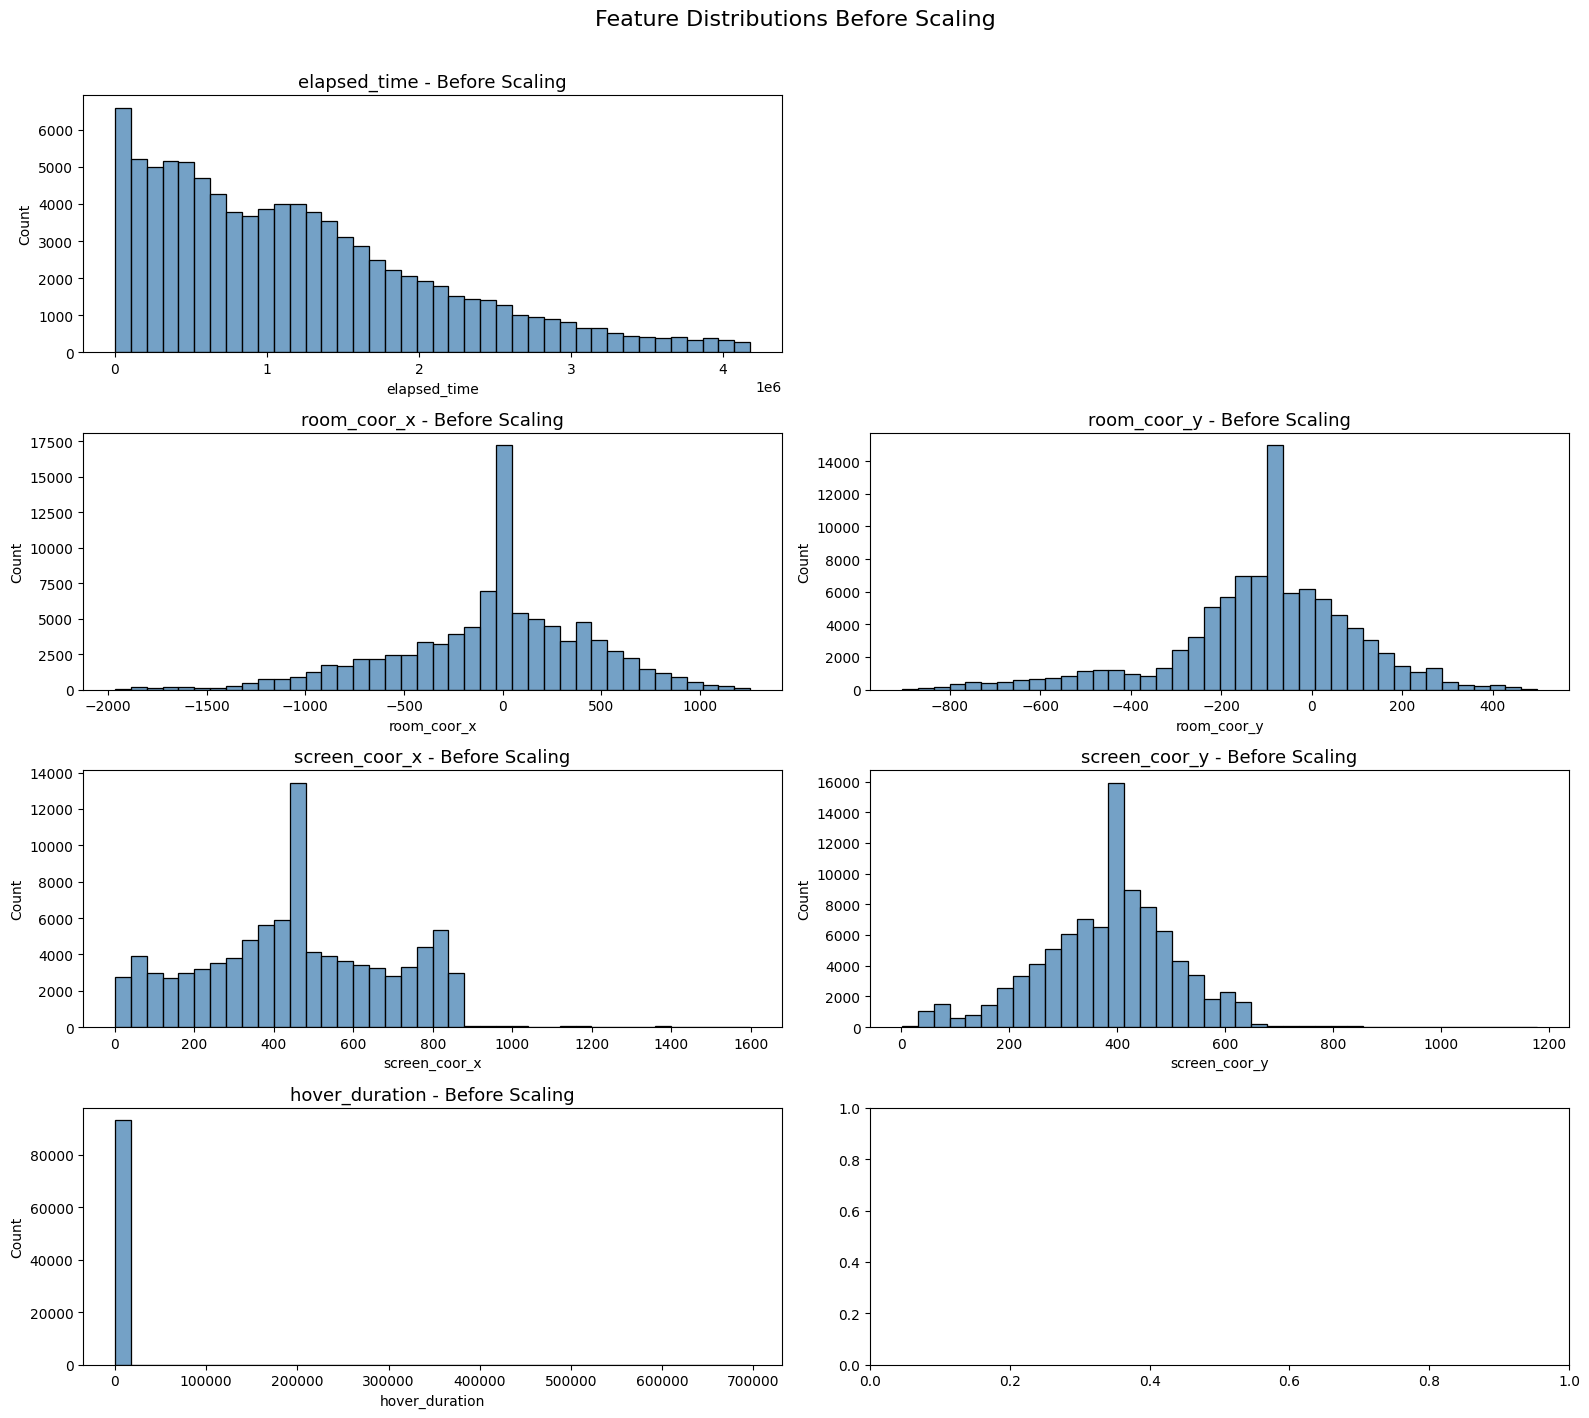

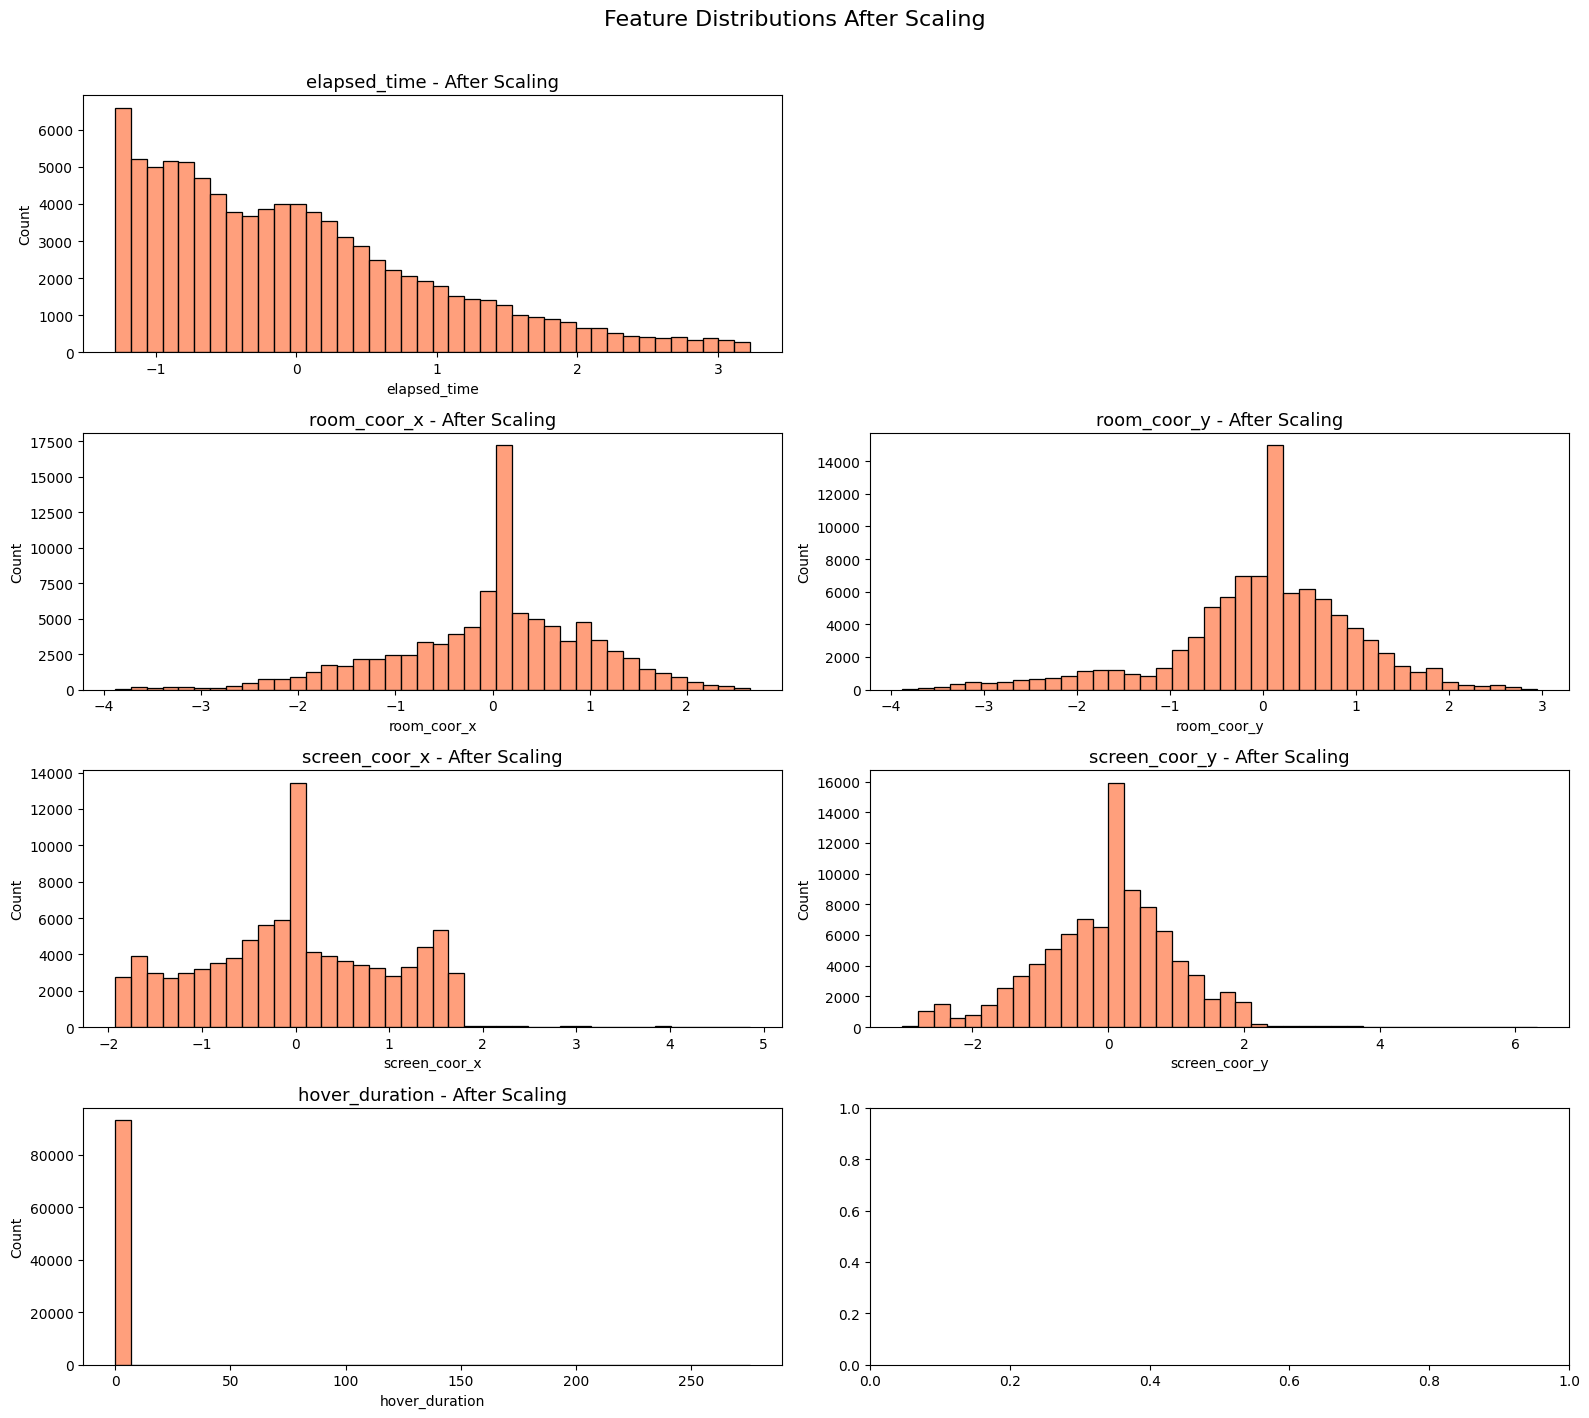

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define all numerical features to visualize
numeric_cols = ['elapsed_time', 'level', 'room_coor_x', 'room_coor_y', 'screen_coor_x', 'screen_coor_y', 'hover_duration']

# BEFORE SCALING PLOT
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    # Check if feature exists in current dataframe structure
    if feature in X.columns:
        sns.histplot(data=X, x=feature, ax=axes[i], bins=40, color='steelblue')
        axes[i].set_title(f'{feature} - Before Scaling', fontsize=13)
        axes[i].set_ylabel('Count')

# Correctly hide the 8th empty subplot (index 7)
axes[1].set_visible(False)

plt.suptitle('Feature Distributions Before Scaling', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# APPLY SCALING
# Apply standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# AFTER SCALING PLOT 
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    if feature in X_scaled_df.columns:
        sns.histplot(data=X_scaled_df, x=feature, ax=axes[i], bins=40, color='coral')
        axes[i].set_title(f'{feature} - After Scaling', fontsize=13)
        axes[i].set_ylabel('Count')

# Correctly hide the 8th empty subplot (index 7)
axes[1].set_visible(False)

plt.suptitle('Feature Distributions After Scaling', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 7. Machine Learning

**Problem Formulation**

**Input:** 31 scaled numerical and one-hot encoded categorical features.

**Output:** Binary label (0 = Incorrect, 1 = Correct).

**Models:** Random Forest and Logistic Regression.

**Metrics:** Accuracy and F1-Score (Kaggle Metric).

**Split:** 64% train / 16% validation / 20% local test (stratified to preserve class balance).


**1. Train / Validation Split**

Split training sample into train, validation, and test sub-samples

In [220]:
# Using a "stratify=y" during my split to ensure the ratio of correct/incorrect remains consistent across all datasets, and verify it by printing the rates.

from sklearn.model_selection import train_test_split

# 1. First split to set aside the final local test set
X_temp, X_test_local, y_temp, y_test_local = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Second split on the temp data to get train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Train size: {X_train.shape} rows")
print(f"Validation size: {X_val.shape} rows")
print(f"Local Test size: {X_test_local.shape} rows")

# Verify class balance in each split
for name, y_split in [("Train", y_train), ("Val", y_val), ("Local Test", y_test_local)]:
    pos = y_split.mean()
    print(f"{name} Correct rate: {pos:.2%}")


Train size: (59614, 31) rows
Validation size: (14904, 31) rows
Local Test size: (18630, 31) rows
Train Correct rate: 65.61%
Val Correct rate: 65.61%
Local Test Correct rate: 65.60%


The dataset was split into training and validation sets to evaluate model performance on unseen data.

**2. Choosing a Simple and Safe model**

In [221]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

**3. Train Model**

In [222]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

**4. Make Predictions**

In [223]:
y_pred = model.predict(X_val)

**5. Evaluate Performance**

In [224]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.6267444981213097


The model was evaluated using accuracy on the validation set.

In [237]:
from sklearn.metrics import accuracy_score, f1_score

# Compute the usual metric
accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", accuracy)

# Compute the specific Kaggle challenge metric 
f1 = f1_score(y_val, y_pred)
print("Validation F1 Score (Kaggle Metric):", f1)

Validation Accuracy: 0.6267444981213097
Validation F1 Score (Kaggle Metric): 0.7401802811638877


In [226]:
from sklearn.metrics import classification_report

# Detailed classification reports
print("=== Random Forest ===")
print(classification_report(y_val, y_pred, target_names=["Incorrect", "Correct"]))


=== Random Forest ===
              precision    recall  f1-score   support

   Incorrect       0.43      0.28      0.34      5126
     Correct       0.68      0.81      0.74      9778

    accuracy                           0.63     14904
   macro avg       0.56      0.54      0.54     14904
weighted avg       0.60      0.63      0.60     14904



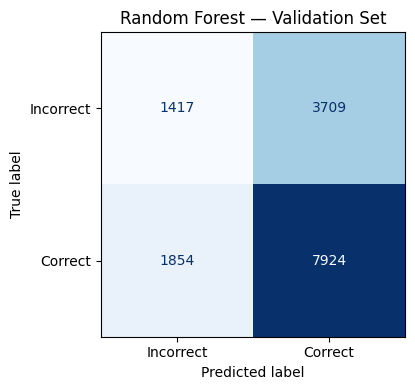

In [227]:
# Using a Confusion Matrix to evaluate binary classification models visually [8, 9].
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix to better understand where the model is making errors
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(
    model, X_val, y_val, 
    display_labels=["Incorrect", "Correct"], 
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title("Random Forest — Validation Set")
plt.tight_layout()
plt.show()


**Evaluate Performance on Local Test Set**

Measuring the generalization performance of the trained model on the 20% held-out local test data.

In [228]:
from sklearn.metrics import accuracy_score

# Evaluate performance on the local test set using the original NumPy array 
# to avoid the feature name mismatch warning
y_test_local_pred = model.predict(X_test_local)
test_local_accuracy = accuracy_score(y_test_local, y_test_local_pred)

print("Local Test Accuracy:", test_local_accuracy)


Local Test Accuracy: 0.6329575952764358


**Secondary Model Comparison**

Training a Logistic Regression model to establish a performance baseline to compare against the Random Forest classifier.

In [229]:
# Try a second algorithm for comparison (Logistic Regression)
from sklearn.linear_model import LogisticRegression

# Initialize and train the secondary model
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# Predict and evaluate on the local test array directly to avoid the warning
y_test_local_pred_lr = model_lr.predict(X_test_local)
test_local_accuracy_lr = accuracy_score(y_test_local, y_test_local_pred_lr)

print("Logistic Regression Local Test Accuracy:", test_local_accuracy_lr)

Logistic Regression Local Test Accuracy: 0.6541062801932367


## 8. Submission

In [238]:
# 1. Applying the exact same cleaning to the test set 
test["hover_duration"] = test["hover_duration"].fillna(0)
test["page"] = test["page"].fillna(-1)
test_clean = test.drop(columns=["index", "text", "fqid", "room_fqid", "text_fqid"], errors="ignore")

# 2. One-hot encode the test set
test_encoded = pd.get_dummies(test_clean, columns=["event_name", "level_group", "name"])

# 3. Align columns so test set matches the features the model was trained on exactly
test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)

# 4. Scale using the ALREADY FITTED scaler
test_scaled = scaler.transform(test_encoded)

# 5. Make final predictions using the NumPy array directly to avoid the warning
test_predictions = model.predict(test_scaled)

# 6. Generate Kaggle submission file
submission = pd.DataFrame({
    "session_id": test["session_id"],
    "correct": test_predictions
})
submission.to_csv("submission.csv", index=False)
print("Submission file 'submission.csv' generated successfully!")


Submission file 'submission.csv' generated successfully!


In [231]:
# Print a preview of the submission file
print("Submission preview:")
display(submission.head())

Submission preview:


,session_id,correct
0,20090109393214576,1
1,20090109393214576,1
2,20090109393214576,1
3,20090109393214576,1
4,20090109393214576,1
